# Phase 3: Exploratory Data Analysis

**Each section answers a specific research question.**

| # | Question |
|---|----------|
| Q1 | Who are the students? (demographics & institutions) |
| Q2 | How prevalent are depression, anxiety, and suicidality? |
| Q3 | Did mental health change from 2023-24 to 2024-25? |
| Q4 | Which demographic groups are most at risk? |
| Q5 | Does financial stress predict mental health outcomes? |
| Q6 | How does loneliness relate to depression and anxiety? |
| Q7 | Does institution type/size affect student mental health? |
| Q8 | How many students need help but don't get it? |
| Q9 | What is the PHQ-9 symptom profile of depressed students? |
| Q10 | Who is most at risk for suicidality? |


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('HMS_clean.csv', low_memory=False)
PHQ9_ITEMS = [f'phq9_{i}' for i in range(1,10)]
GAD7_ITEMS = [f'gad7_{i}' for i in range(1,8)]
YEAR_ORD = ['1st Year','2nd Year','3rd Year','4th Year','5th+ Year']
INST_SIZE_ORD = ['<1k','1-5k','5-10k','10-20k','>20k']
print(f"Loaded: {df.shape[0]:,} students")


Loaded: 189,464 students


## Q1: Who Are the Students?

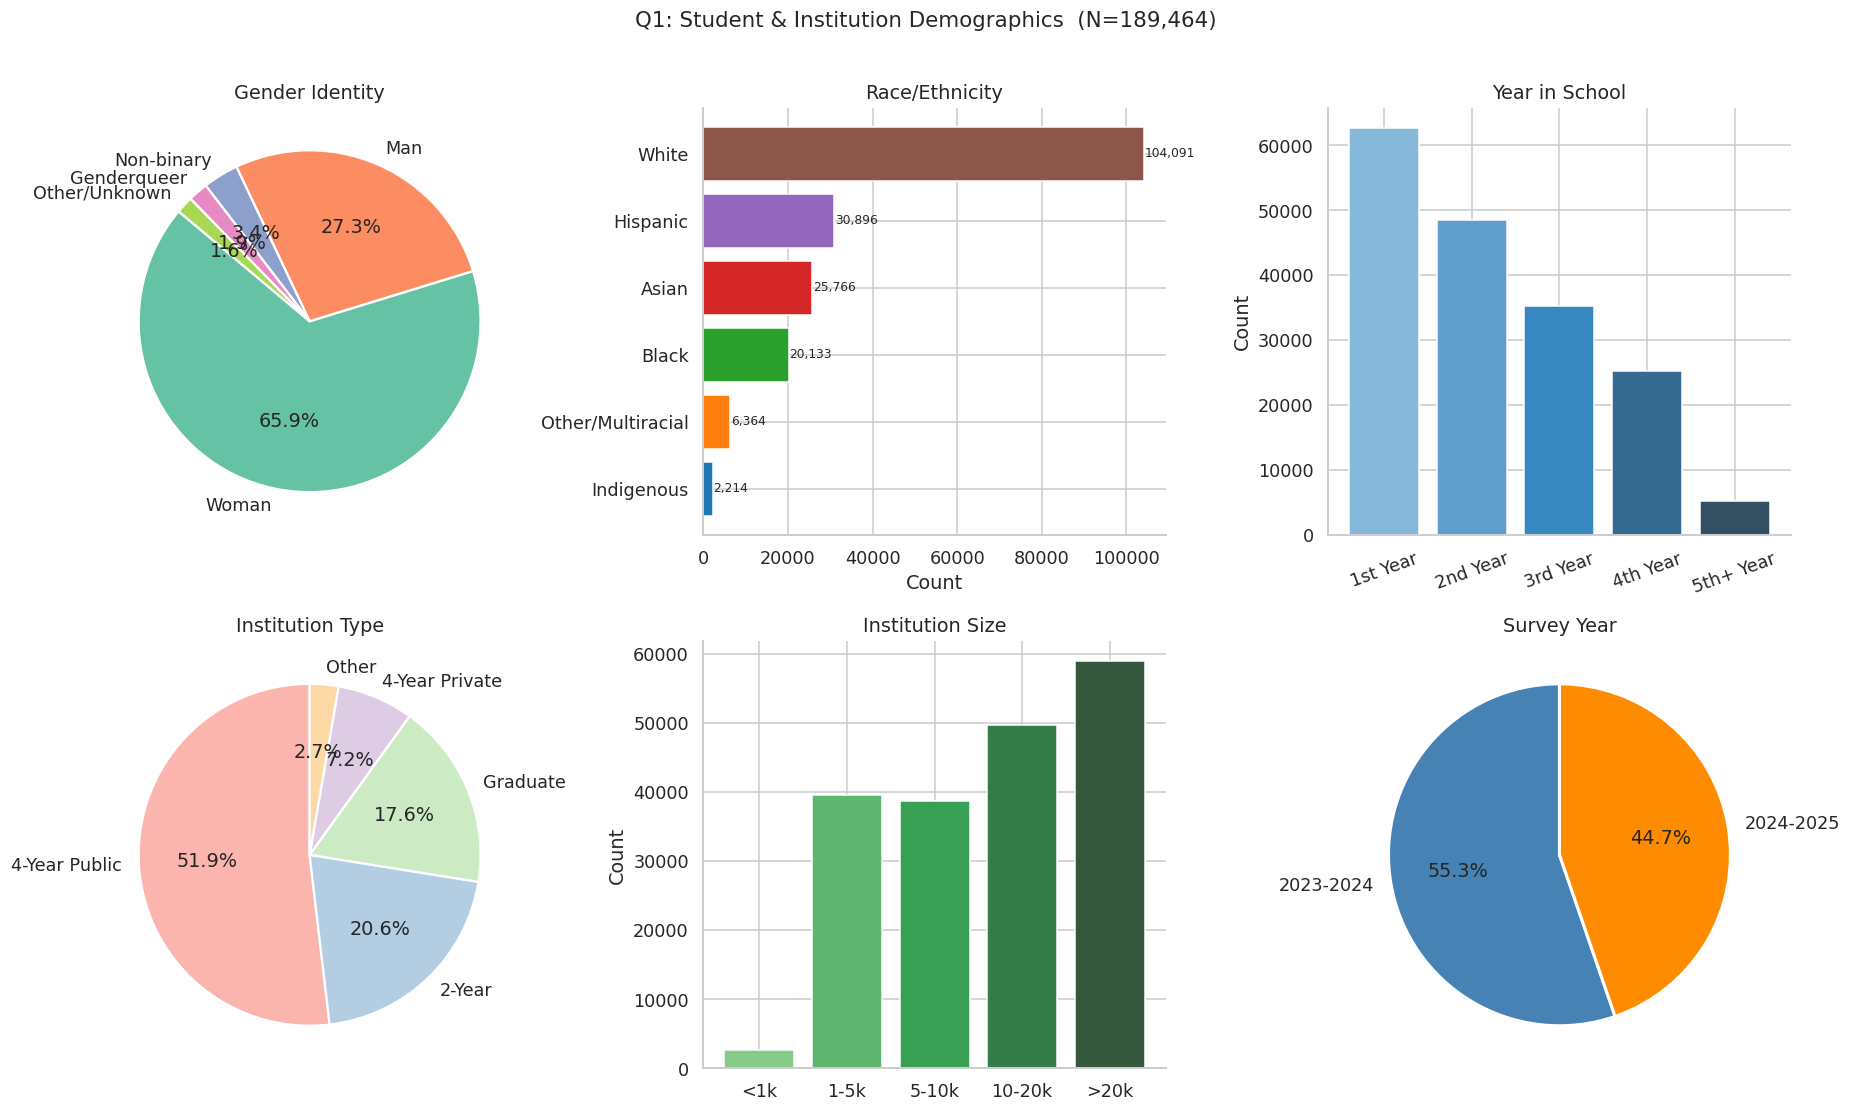

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Gender
g_counts = df['gender'].value_counts()
axes[0,0].pie(g_counts, labels=g_counts.index, autopct='%1.1f%%',
              colors=sns.color_palette('Set2', len(g_counts)), startangle=140,
              wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0,0].set_title('Gender Identity')

# Race
r_counts = df['race'].value_counts()
axes[0,1].barh(r_counts.index[::-1], r_counts.values[::-1],
               color=sns.color_palette('tab10', len(r_counts)))
axes[0,1].set_title('Race/Ethnicity')
axes[0,1].set_xlabel('Count')
for i, v in enumerate(r_counts.values[::-1]):
    axes[0,1].text(v+200, i, f'{v:,}', va='center', fontsize=8)

# Year in school
yr_c = df['year_school'].value_counts().reindex(YEAR_ORD).fillna(0)
axes[0,2].bar(YEAR_ORD, yr_c, color=sns.color_palette('Blues_d', 5))
axes[0,2].set_title('Year in School')
axes[0,2].set_ylabel('Count')
axes[0,2].tick_params(axis='x', rotation=20)

# Institution type
it_c = df['inst_type_label'].value_counts()
axes[1,0].pie(it_c, labels=it_c.index, autopct='%1.1f%%',
              colors=sns.color_palette('Pastel1', len(it_c)), startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1,0].set_title('Institution Type')

# Institution size
is_c = df['inst_size_label'].value_counts().reindex(INST_SIZE_ORD).fillna(0)
axes[1,1].bar(INST_SIZE_ORD, is_c, color=sns.color_palette('Greens_d', 5))
axes[1,1].set_title('Institution Size')
axes[1,1].set_ylabel('Count')

# Survey year
yr_survey = df['year'].value_counts()
axes[1,2].pie(yr_survey, labels=yr_survey.index, autopct='%1.1f%%',
              colors=['steelblue','darkorange'], startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[1,2].set_title('Survey Year')

plt.suptitle('Q1: Student & Institution Demographics  (N={:,})'.format(len(df)), fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

## Q2: How Prevalent Are Depression, Anxiety, and Suicidality?

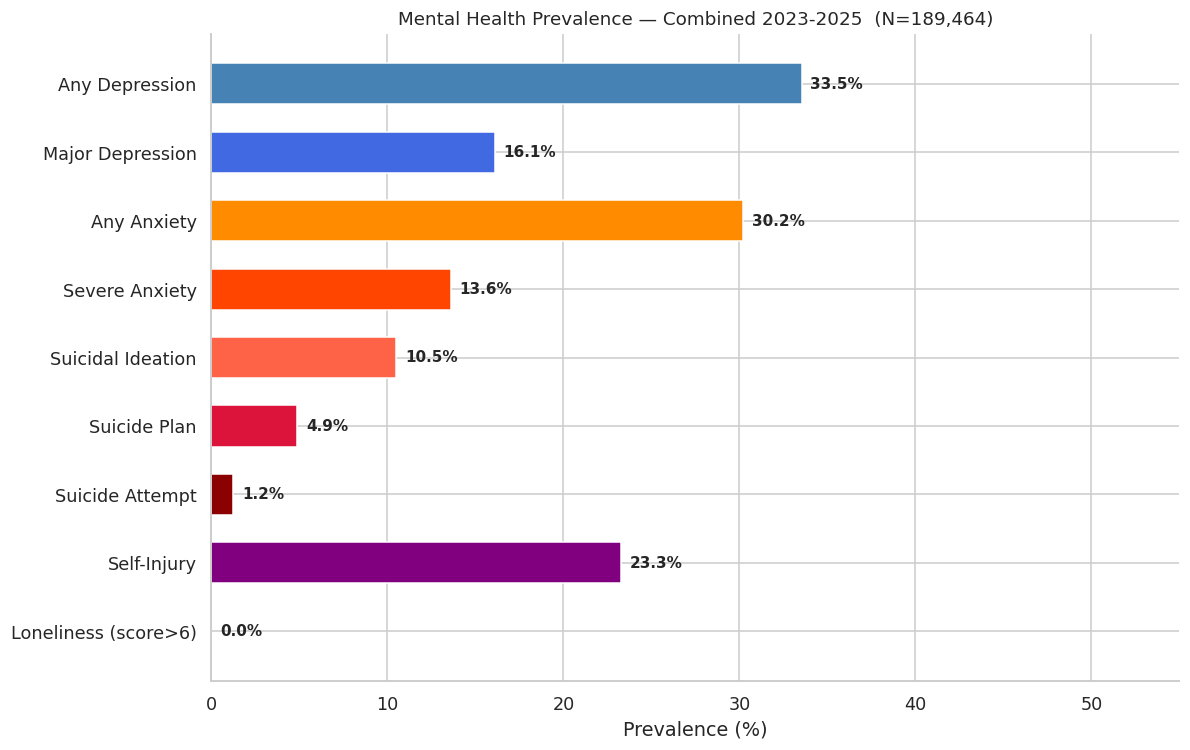

In [3]:
outcomes = [
    ('dep_any',  'Any Depression',       'steelblue'),
    ('dep_maj',  'Major Depression',     'royalblue'),
    ('anx_any',  'Any Anxiety',          'darkorange'),
    ('anx_sev',  'Severe Anxiety',       'orangered'),
    ('sui_idea', 'Suicidal Ideation',    'tomato'),
    ('sui_plan', 'Suicide Plan',         'crimson'),
    ('sui_att',  'Suicide Attempt',      'darkred'),
    ('sib_any',  'Self-Injury',          'purple'),
    ('lonely',   'Loneliness (score>6)', 'mediumpurple'),
]

fig, ax = plt.subplots(figsize=(11, 7))
labels, pcts, colors = [], [], []
for col, label, color in outcomes:
    if col in df.columns:
        if col == 'lonely':
            pct = (pd.to_numeric(df[col], errors='coerce') > 6).mean() * 100
        else:
            pct = pd.to_numeric(df[col], errors='coerce').eq(1).mean() * 100
        labels.append(label); pcts.append(pct); colors.append(color)

bars = ax.barh(labels[::-1], pcts[::-1], color=colors[::-1], edgecolor='white', height=0.6)
ax.set_xlabel('Prevalence (%)')
ax.set_title('Mental Health Prevalence — Combined 2023-2025  (N={:,})'.format(len(df)), fontsize=12)
ax.set_xlim(0, 55)
for bar, pct in zip(bars, pcts[::-1]):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontweight='bold', fontsize=10)
plt.tight_layout(); plt.show()

## Q3: Did Mental Health Change from 2023-24 to 2024-25?

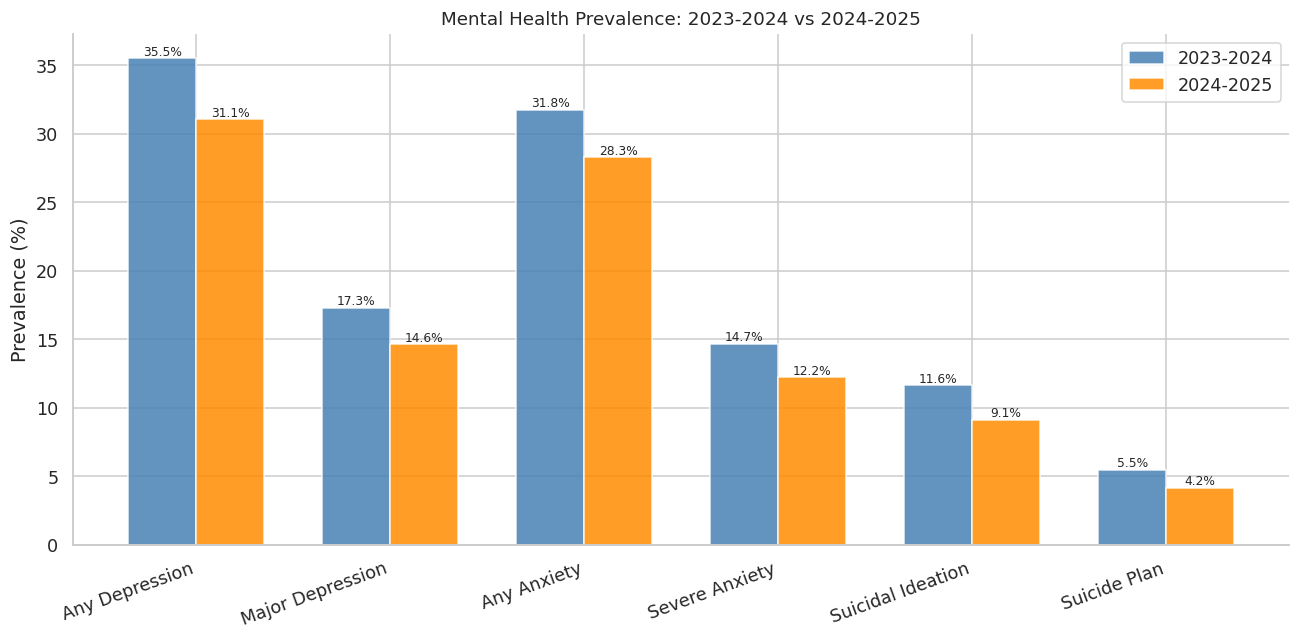

Year-over-year changes:
  Any Depression           : 35.5% → 31.1%  ↓4.5pp
  Major Depression         : 17.3% → 14.6%  ↓2.7pp
  Any Anxiety              : 31.8% → 28.3%  ↓3.5pp
  Severe Anxiety           : 14.7% → 12.2%  ↓2.4pp
  Suicidal Ideation        : 11.6% → 9.1%  ↓2.5pp
  Suicide Plan             : 5.5% → 4.2%  ↓1.3pp


In [4]:
compare_cols = [
    ('dep_any',  'Any Depression'),
    ('dep_maj',  'Major Depression'),
    ('anx_any',  'Any Anxiety'),
    ('anx_sev',  'Severe Anxiety'),
    ('sui_idea', 'Suicidal Ideation'),
    ('sui_plan', 'Suicide Plan'),
]

rows_data = []
for col, label in compare_cols:
    if col in df.columns:
        for yr in ['2023-2024','2024-2025']:
            sub = df[df['year']==yr]
            pct = pd.to_numeric(sub[col], errors='coerce').eq(1).mean()*100
            rows_data.append({'Outcome': label, 'Year': yr, 'Prevalence': pct})

comp_df = pd.DataFrame(rows_data)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comp_df['Outcome'].unique()))
w = 0.35
outcomes_list = comp_df['Outcome'].unique()
for i, (yr, color) in enumerate([('2023-2024','steelblue'),('2024-2025','darkorange')]):
    vals = [comp_df[(comp_df['Outcome']==o)&(comp_df['Year']==yr)]['Prevalence'].values[0]
            for o in outcomes_list]
    bars = ax.bar(x + i*w - w/2, vals, w, label=yr, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.annotate(f'{val:.1f}%', (bar.get_x()+bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(outcomes_list, rotation=20, ha='right')
ax.set_ylabel('Prevalence (%)')
ax.set_title('Mental Health Prevalence: 2023-2024 vs 2024-2025', fontsize=12)
ax.legend()
plt.tight_layout(); plt.show()

print("Year-over-year changes:")
for o in outcomes_list:
    v23 = comp_df[(comp_df['Outcome']==o)&(comp_df['Year']=='2023-2024')]['Prevalence'].values[0]
    v24 = comp_df[(comp_df['Outcome']==o)&(comp_df['Year']=='2024-2025')]['Prevalence'].values[0]
    delta = v24 - v23
    arrow = '↓' if delta < 0 else '↑'
    print(f"  {o:25s}: {v23:.1f}% → {v24:.1f}%  {arrow}{abs(delta):.1f}pp")

## Q4: Which Demographic Groups Are Most At Risk?

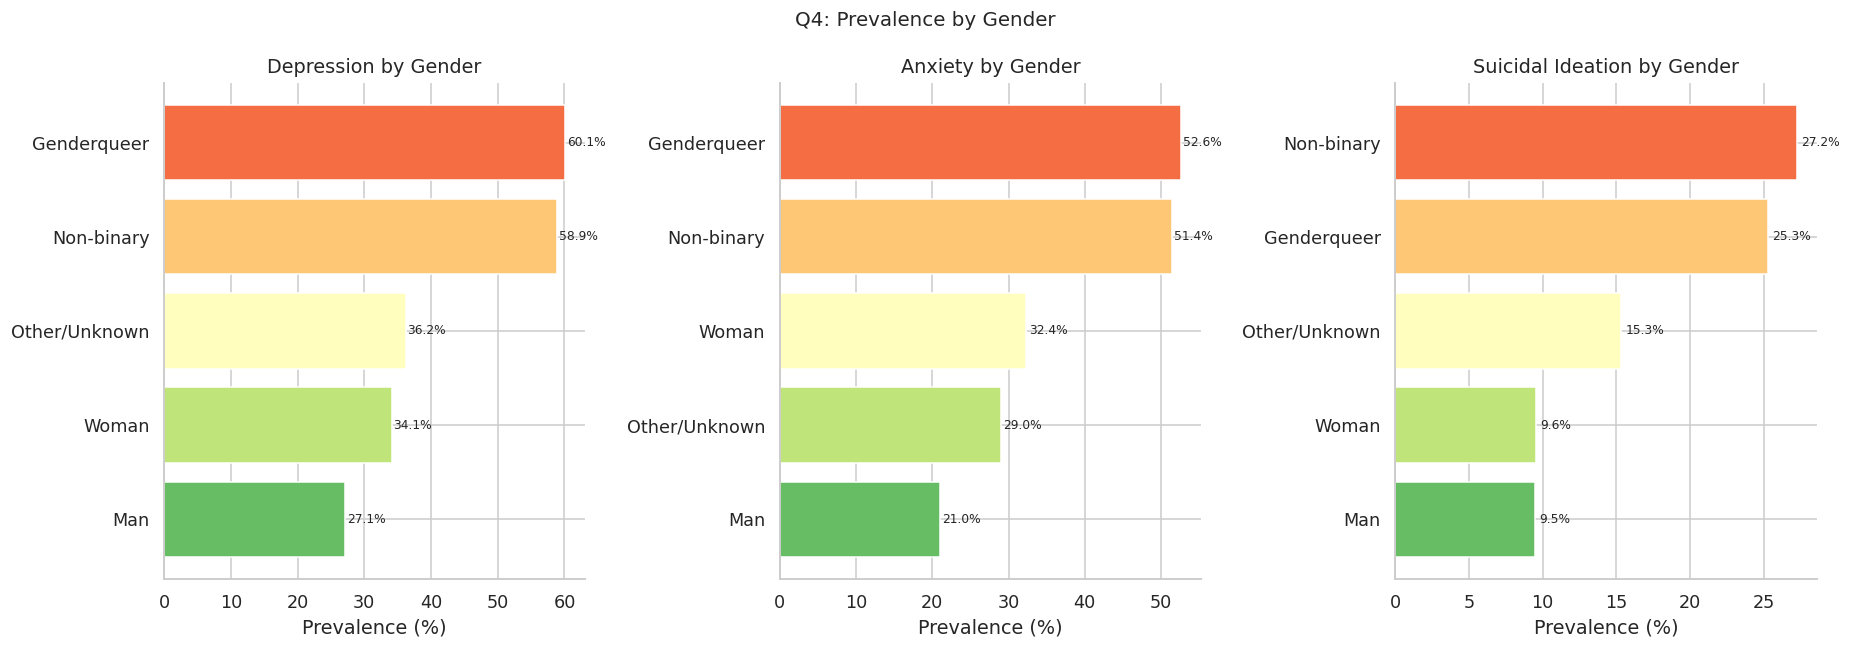

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
risk_outcomes = [('dep_any','Depression'),('anx_any','Anxiety'),('sui_idea','Suicidal Ideation')]

for ax, (col, title) in zip(axes, risk_outcomes):
    group_rates = {}
    for group in ['gender','race','year_school']:
        rates = df.groupby(group)[col].apply(
            lambda x: pd.to_numeric(x, errors='coerce').eq(1).mean()*100)
        group_rates[group] = rates

    # Plot by gender
    gender_rates = df.groupby('gender')[col].apply(
        lambda x: pd.to_numeric(x, errors='coerce').eq(1).mean()*100).sort_values(ascending=True)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(gender_rates)))
    ax.barh(gender_rates.index, gender_rates.values, color=colors, edgecolor='white')
    ax.set_title(f'{title} by Gender')
    ax.set_xlabel('Prevalence (%)')
    for i, v in enumerate(gender_rates.values):
        ax.text(v+0.3, i, f'{v:.1f}%', va='center', fontsize=8)

plt.suptitle('Q4: Prevalence by Gender', fontsize=13)
plt.tight_layout(); plt.show()

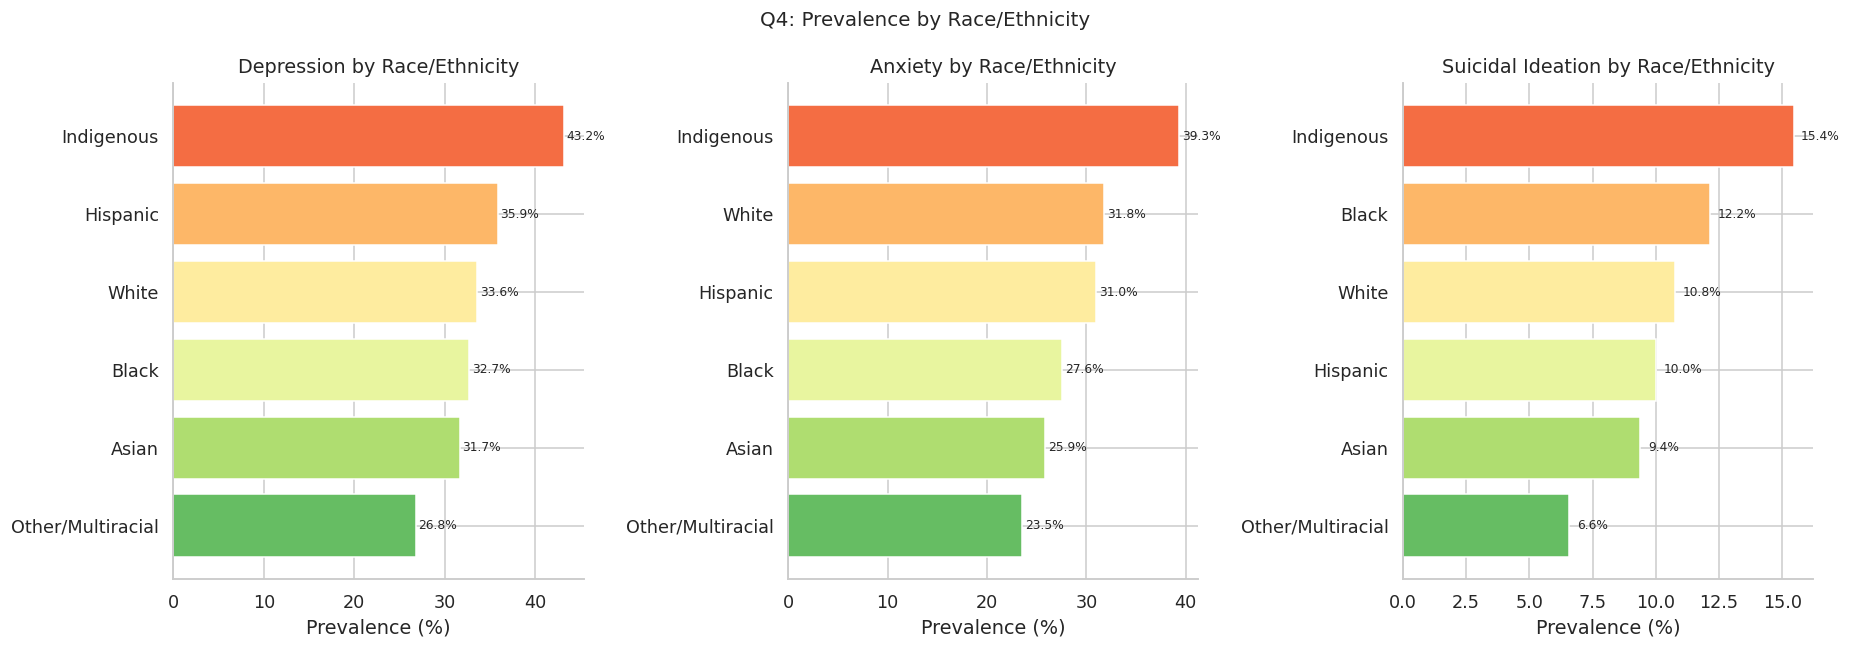

In [6]:
# By race
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
for ax, (col, title) in zip(axes, risk_outcomes):
    race_rates = df.groupby('race')[col].apply(
        lambda x: pd.to_numeric(x, errors='coerce').eq(1).mean()*100).sort_values(ascending=True)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(race_rates)))
    ax.barh(race_rates.index, race_rates.values, color=colors, edgecolor='white')
    ax.set_title(f'{title} by Race/Ethnicity')
    ax.set_xlabel('Prevalence (%)')
    for i, v in enumerate(race_rates.values):
        ax.text(v+0.3, i, f'{v:.1f}%', va='center', fontsize=8)
plt.suptitle('Q4: Prevalence by Race/Ethnicity', fontsize=13)
plt.tight_layout(); plt.show()

## Q5: Does Financial Stress Predict Mental Health Outcomes?

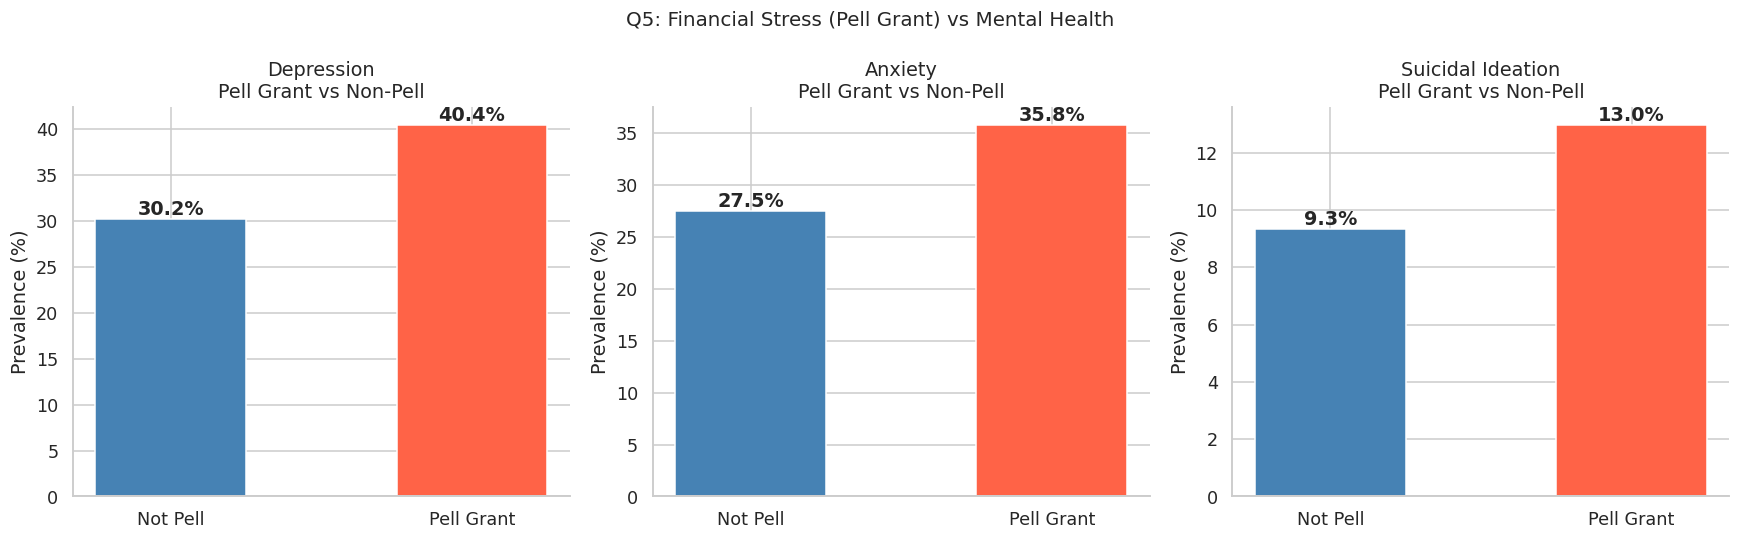

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, title) in zip(axes, [('dep_any','Depression'),('anx_any','Anxiety'),('sui_idea','Suicidal Ideation')]):
    # Pell grant (low income proxy)
    pell_rates = df.groupby('low_income')[col].apply(
        lambda x: pd.to_numeric(x, errors='coerce').eq(1).mean()*100)
    pell_rates.index = ['Not Pell','Pell Grant']
    bars = ax.bar(pell_rates.index, pell_rates.values,
                  color=['steelblue','tomato'], edgecolor='white', width=0.5)
    ax.set_title(f'{title}\nPell Grant vs Non-Pell')
    ax.set_ylabel('Prevalence (%)')
    for bar, val in zip(bars, pell_rates.values):
        ax.annotate(f'{val:.1f}%', (bar.get_x()+bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontweight='bold')

plt.suptitle('Q5: Financial Stress (Pell Grant) vs Mental Health', fontsize=13)
plt.tight_layout(); plt.show()

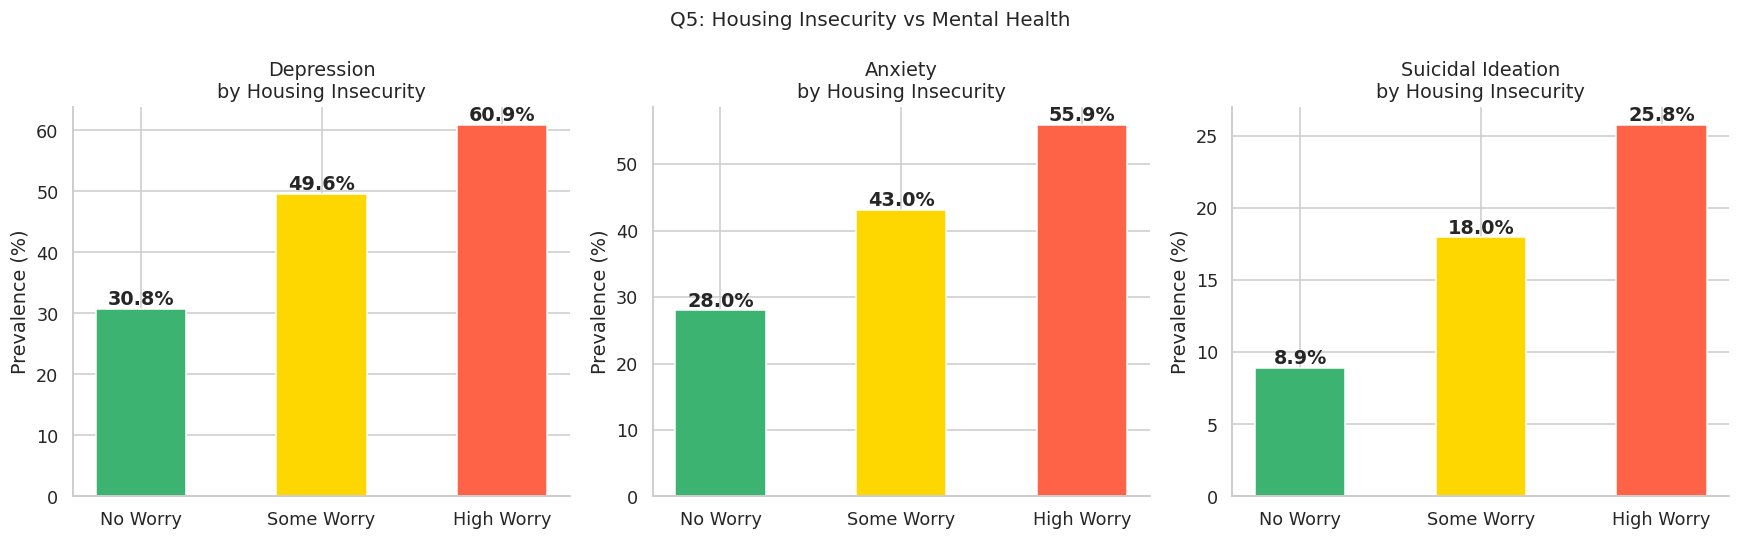

In [8]:
# Housing insecurity
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
housing_labels = {1:'No Worry',2:'Some Worry',3:'High Worry'}
for ax, (col, title) in zip(axes, [('dep_any','Depression'),('anx_any','Anxiety'),('sui_idea','Suicidal Ideation')]):
    df['housing_worry_n'] = pd.to_numeric(df['housing_worry'], errors='coerce')
    h_rates = df.groupby('housing_worry_n')[col].apply(
        lambda x: pd.to_numeric(x, errors='coerce').eq(1).mean()*100).reindex([1,2,3])
    h_rates.index = ['No Worry','Some Worry','High Worry']
    bars = ax.bar(h_rates.index, h_rates.values,
                  color=['mediumseagreen','gold','tomato'], edgecolor='white', width=0.5)
    ax.set_title(f'{title}\nby Housing Insecurity')
    ax.set_ylabel('Prevalence (%)')
    for bar, val in zip(bars, h_rates.values):
        if not np.isnan(val):
            ax.annotate(f'{val:.1f}%', (bar.get_x()+bar.get_width()/2, bar.get_height()),
                        ha='center', va='bottom', fontweight='bold')
plt.suptitle('Q5: Housing Insecurity vs Mental Health', fontsize=13)
plt.tight_layout(); plt.show()

## Q6: How Does Loneliness Relate to Depression and Anxiety?

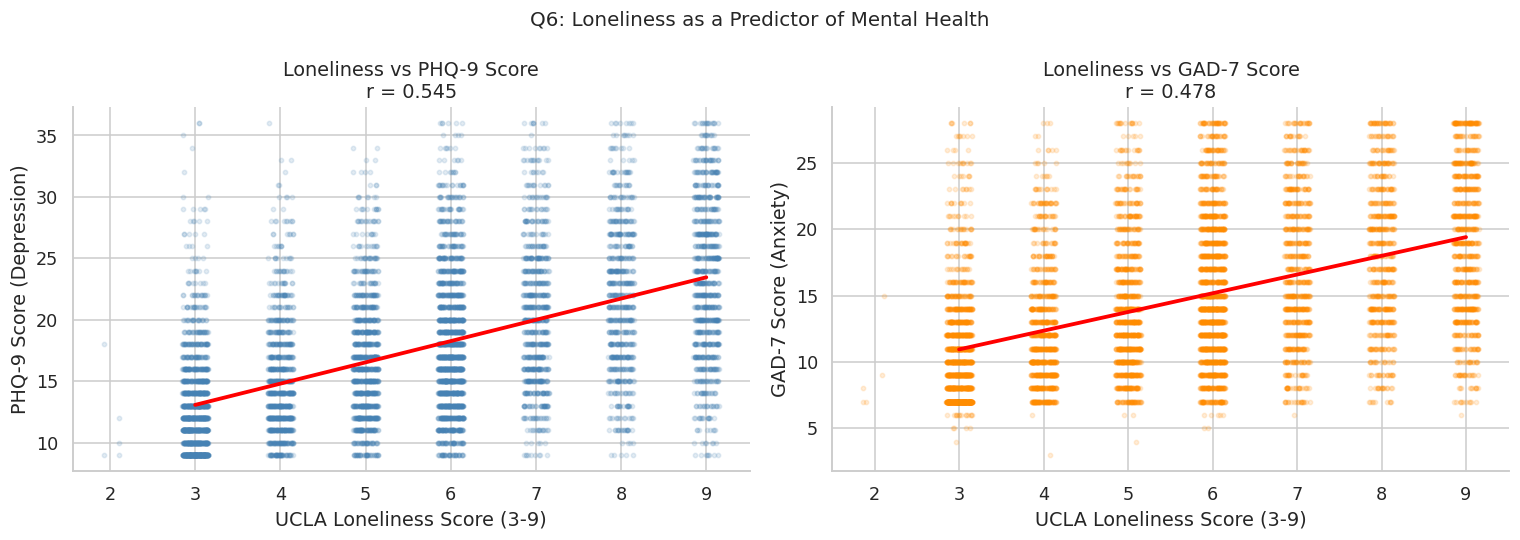

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['loneliness_n'] = pd.to_numeric(df['loneliness'], errors='coerce')
df['phq9_total_n'] = pd.to_numeric(df['phq9_total'], errors='coerce')
df['gad7_total_n'] = pd.to_numeric(df['gad7_total'], errors='coerce')

sample = df[['loneliness_n','phq9_total_n','gad7_total_n','dep_any']].dropna().sample(
    n=min(8000, len(df)), random_state=42)

for ax, (ycol, ylabel, color) in zip(axes, [
    ('phq9_total_n','PHQ-9 Score (Depression)','steelblue'),
    ('gad7_total_n','GAD-7 Score (Anxiety)','darkorange')]):
    ax.scatter(sample['loneliness_n'] + np.random.uniform(-0.15,0.15,len(sample)),
               sample[ycol], alpha=0.15, s=8, color=color)
    m, b = np.polyfit(sample['loneliness_n'].dropna(), sample[ycol].dropna(), 1)
    xline = np.linspace(3, 9, 100)
    ax.plot(xline, m*xline+b, color='red', linewidth=2.5)
    r = sample[['loneliness_n',ycol]].corr().iloc[0,1]
    ax.set_xlabel('UCLA Loneliness Score (3-9)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Loneliness vs {ylabel.split("(")[0].strip()}\nr = {r:.3f}')

plt.suptitle('Q6: Loneliness as a Predictor of Mental Health', fontsize=13)
plt.tight_layout(); plt.show()

## Q7: Does Institution Type/Size Affect Student Mental Health?

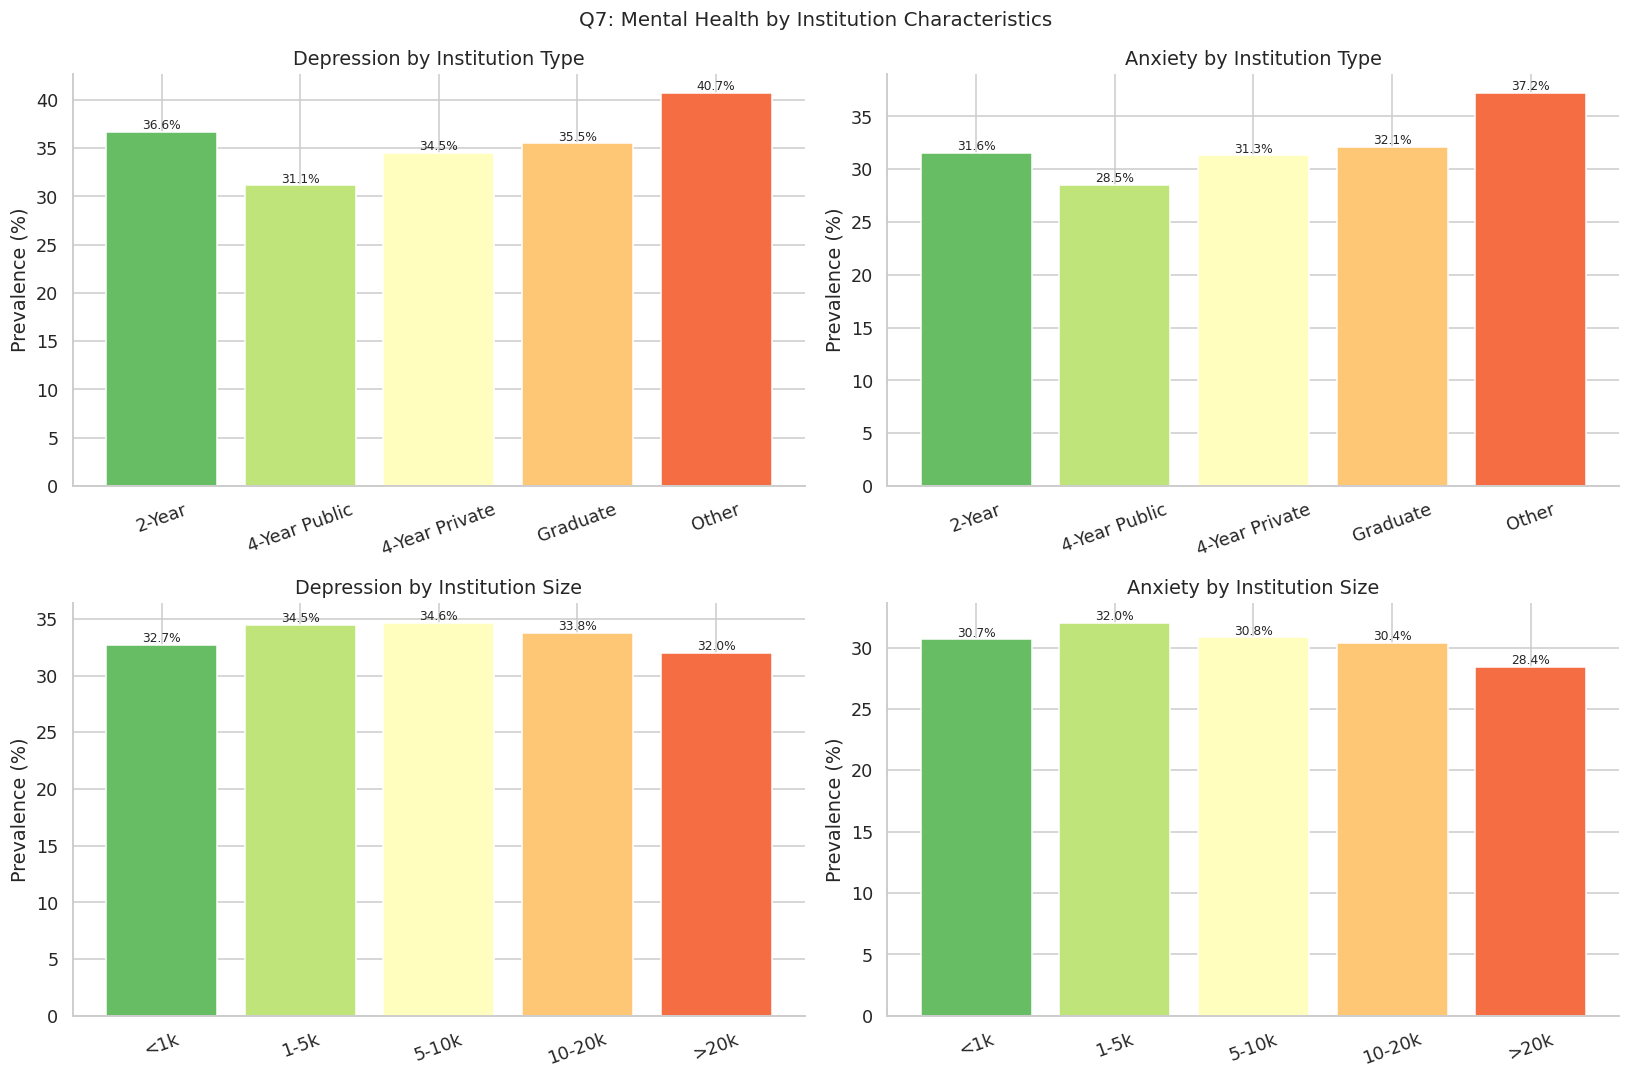

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for row_axes, group_col, group_ord, title in [
    (axes[0], 'inst_type_label', ['2-Year','4-Year Public','4-Year Private','Graduate','Other'], 'Institution Type'),
    (axes[1], 'inst_size_label', INST_SIZE_ORD, 'Institution Size'),
]:
    for ax, (col, label) in zip(row_axes, [('dep_any','Depression'),('anx_any','Anxiety')]):
        rates = df.groupby(group_col)[col].apply(
            lambda x: pd.to_numeric(x, errors='coerce').eq(1).mean()*100)
        order_present = [o for o in group_ord if o in rates.index]
        rates = rates.reindex(order_present)
        colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(rates)))
        bars = ax.bar(rates.index, rates.values, color=colors, edgecolor='white')
        ax.set_title(f'{label} by {title}')
        ax.set_ylabel('Prevalence (%)')
        ax.tick_params(axis='x', rotation=20)
        for bar, val in zip(bars, rates.values):
            if not np.isnan(val):
                ax.annotate(f'{val:.1f}%', (bar.get_x()+bar.get_width()/2, bar.get_height()),
                            ha='center', va='bottom', fontsize=8)

plt.suptitle('Q7: Mental Health by Institution Characteristics', fontsize=13)
plt.tight_layout(); plt.show()

## Q8: How Many Students Need Help But Don't Get It?

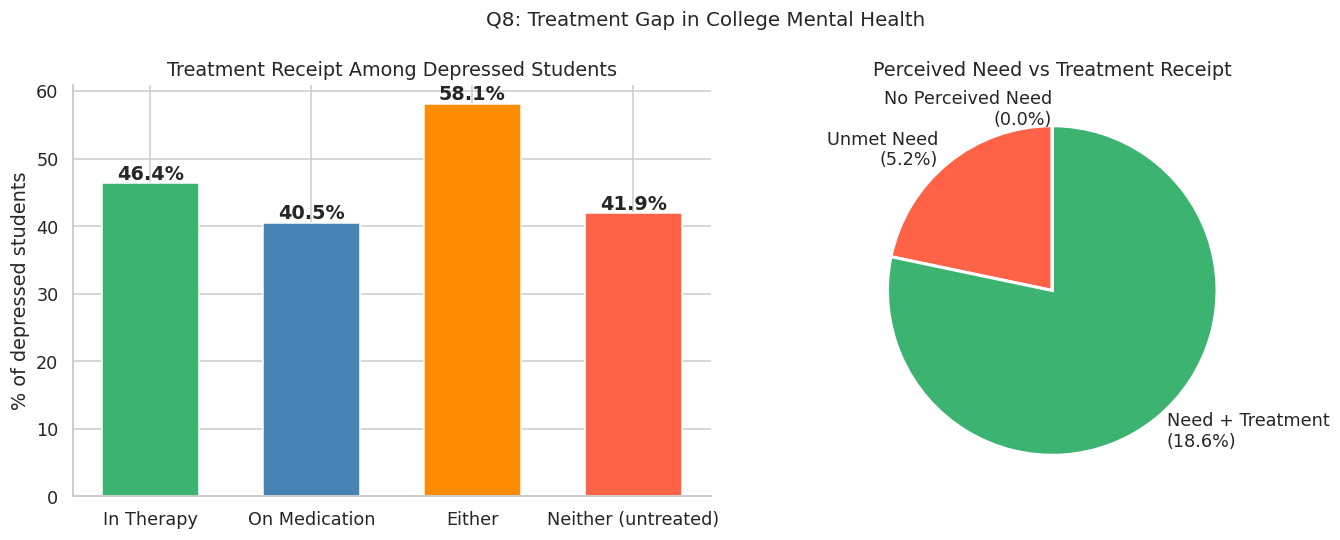

Depressed students NOT in treatment: 41.9%
Students with unmet need: 5.2%


In [11]:
df['percneed_n']     = pd.to_numeric(df['percneed'],     errors='coerce')
df['percneed_cur_n'] = pd.to_numeric(df['percneed_cur'], errors='coerce')
df['ther_any_n']     = pd.to_numeric(df['ther_any'],     errors='coerce')
df['meds_any_n']     = pd.to_numeric(df['meds_any'],     errors='coerce')
df['dep_any_n']      = pd.to_numeric(df['dep_any'],      errors='coerce')

# Among depressed students: who gets treatment?
dep = df[df['dep_any_n']==1]
in_therapy = dep['ther_any_n'].eq(1).mean()*100
on_meds    = dep['meds_any_n'].eq(1).mean()*100
either     = dep[['ther_any_n','meds_any_n']].max(axis=1).eq(1).mean()*100
neither    = 100 - either

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Treatment receipt among depressed
labels_tx = ['In Therapy','On Medication','Either','Neither (untreated)']
vals_tx   = [in_therapy, on_meds, either, neither]
colors_tx = ['mediumseagreen','steelblue','darkorange','tomato']
bars = axes[0].bar(labels_tx, vals_tx, color=colors_tx, edgecolor='white', width=0.6)
axes[0].set_title('Treatment Receipt Among Depressed Students')
axes[0].set_ylabel('% of depressed students')
for bar, val in zip(bars, vals_tx):
    axes[0].annotate(f'{val:.1f}%', (bar.get_x()+bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Perceived need vs treatment
need_no_tx = df[(df['percneed_cur_n']==1) & (df['ther_any_n']==0) & (df['meds_any_n']==0)]
need_tx    = df[(df['percneed_cur_n']==1) & ((df['ther_any_n']==1) | (df['meds_any_n']==1))]
no_need    = df[df['percneed_cur_n']==0]
total_valid = df['percneed_cur_n'].notna().sum()

slices = [len(need_no_tx)/total_valid*100, len(need_tx)/total_valid*100, len(no_need)/total_valid*100]
slice_labels = [f'Unmet Need\n({slices[0]:.1f}%)', f'Need + Treatment\n({slices[1]:.1f}%)',
                f'No Perceived Need\n({slices[2]:.1f}%)']
axes[1].pie(slices, labels=slice_labels, colors=['tomato','mediumseagreen','steelblue'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Perceived Need vs Treatment Receipt')

plt.suptitle('Q8: Treatment Gap in College Mental Health', fontsize=13)
plt.tight_layout(); plt.show()
print(f"Depressed students NOT in treatment: {neither:.1f}%")
print(f"Students with unmet need: {slices[0]:.1f}%")

## Q9: PHQ-9 Symptom Profile of Depressed vs Non-Depressed Students

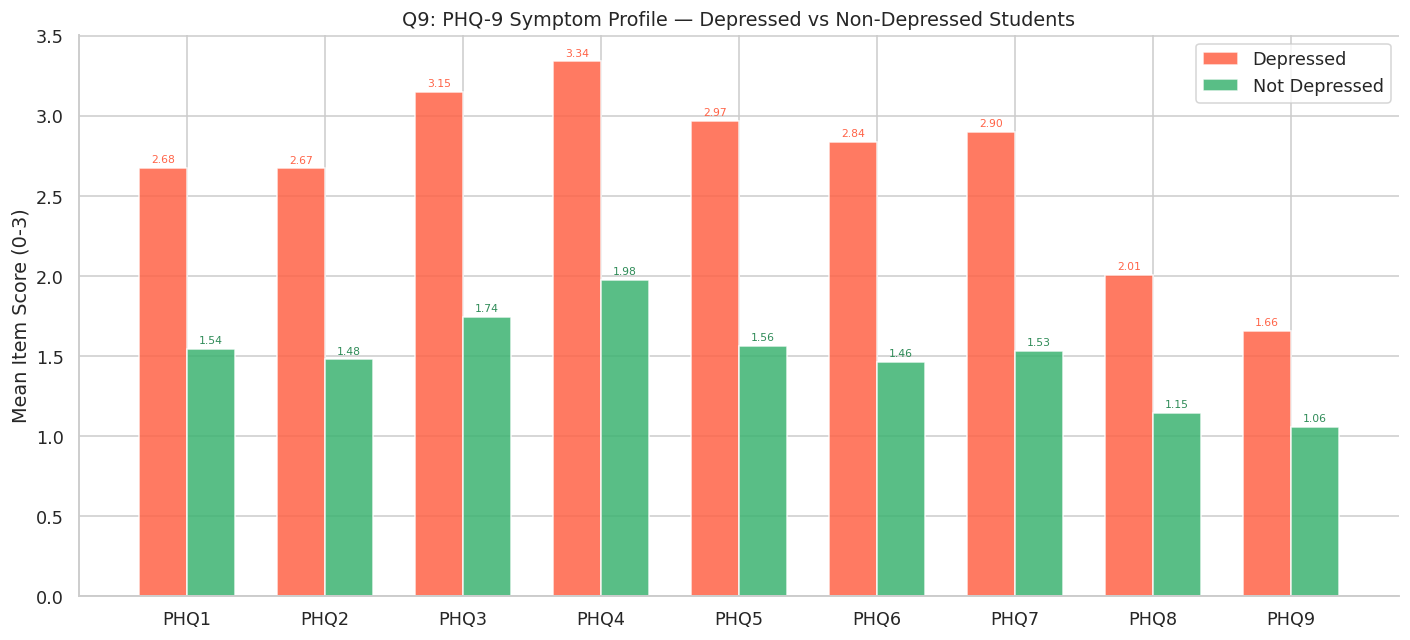

In [12]:
phq_labels = [
    'PHQ1: Little interest/pleasure',
    'PHQ2: Feeling down/hopeless',
    'PHQ3: Sleep problems',
    'PHQ4: Tired/little energy',
    'PHQ5: Poor appetite/overeating',
    'PHQ6: Feeling like a failure',
    'PHQ7: Trouble concentrating',
    'PHQ8: Moving/speaking slowly',
    'PHQ9: Self-harm thoughts',
]
phq_present = [c for c in PHQ9_ITEMS if c in df.columns]

dep_group   = df[df['dep_any_n']==1][phq_present].apply(pd.to_numeric, errors='coerce').mean()
nodep_group = df[df['dep_any_n']==0][phq_present].apply(pd.to_numeric, errors='coerce').mean()

x = np.arange(len(phq_present)); w = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x-w/2, dep_group.values,   w, label='Depressed',     color='tomato',        alpha=0.85, edgecolor='white')
ax.bar(x+w/2, nodep_group.values, w, label='Not Depressed', color='mediumseagreen', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([l.split(':')[0] for l in phq_labels], rotation=0)
ax.set_ylabel('Mean Item Score (0-3)')
ax.set_title('Q9: PHQ-9 Symptom Profile — Depressed vs Non-Depressed Students')
ax.legend()
for i, (d, nd) in enumerate(zip(dep_group.values, nodep_group.values)):
    ax.text(i-w/2, d+0.02, f'{d:.2f}', ha='center', va='bottom', fontsize=7, color='tomato')
    ax.text(i+w/2, nd+0.02, f'{nd:.2f}', ha='center', va='bottom', fontsize=7, color='seagreen')
plt.tight_layout(); plt.show()

## Q10: Who Is Most At Risk for Suicidality?

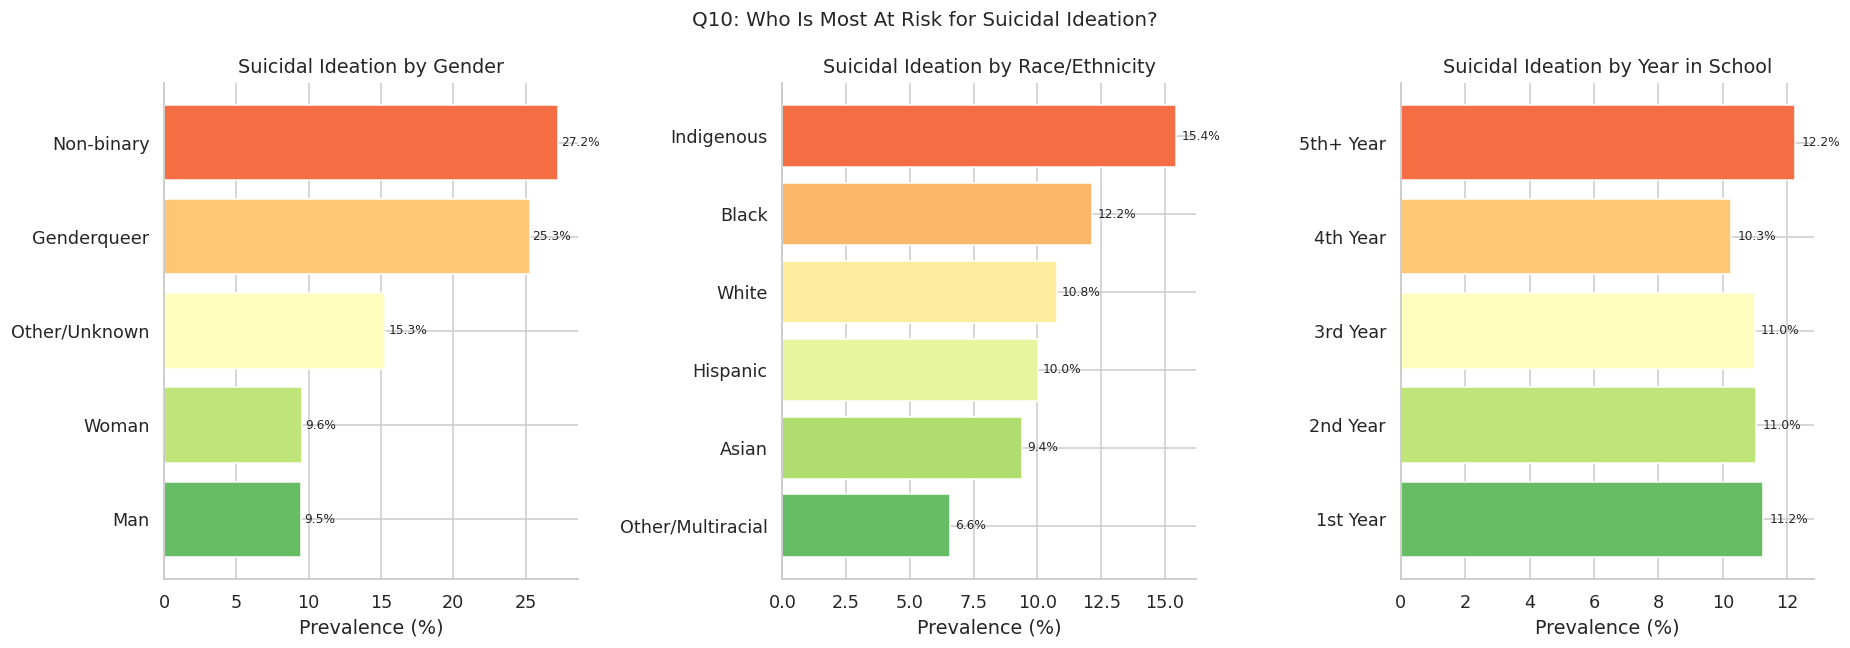

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

for ax, (group_col, title) in zip(axes, [
    ('gender',       'Gender'),
    ('race',         'Race/Ethnicity'),
    ('year_school',  'Year in School'),
]):
    rates = df.groupby(group_col)['sui_idea'].apply(
        lambda x: pd.to_numeric(x, errors='coerce').eq(1).mean()*100).sort_values(ascending=True)
    if group_col == 'year_school':
        rates = rates.reindex([y for y in YEAR_ORD if y in rates.index])
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(rates)))
    ax.barh(rates.index, rates.values, color=colors, edgecolor='white')
    ax.set_title(f'Suicidal Ideation by {title}')
    ax.set_xlabel('Prevalence (%)')
    for i, v in enumerate(rates.values):
        ax.text(v+0.2, i, f'{v:.1f}%', va='center', fontsize=8)

plt.suptitle('Q10: Who Is Most At Risk for Suicidal Ideation?', fontsize=13)
plt.tight_layout(); plt.show()